# NBA Shot Quality Model

Predicts the probability an NBA shot goes in using SportVU player tracking data from the 2014-15 season.
It is less about hard yes/no classification, more about estimating shot quality the way front offices like to actually think about it.

Run all cells top to bottom.


## Setup

In [ ]:
# Run this cell first, creates the folders the rest of the notebook expects
import os
# run from the repo root so the relative data/ paths resolve
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)
# If on Colab, upload shot_logs.csv from https://www.kaggle.com/datasets/dansbecker/nba-shot-logs
# into the data/ folder via the left sidebar before continuing
print("folders ready")

folders ready


## Imports

In [ ]:
%matplotlib inline
import time
import random
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

# Sklearn utilities for splitting, preprocessing, and metrics
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, log_loss, brier_score_loss, roc_auc_score,
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
SEED = 42
print("imports done")


imports done


## 1. Data cleaning

Raw data from the 2014-15 NBA season via Kaggle. SportVU tracking captured defender positions,
shot clock data, and ball-handling info per shot.

the cleaning steps:
- parse GAME_CLOCK string (m:ss) into total seconds
- clip negative TOUCH_TIME values (sportvu sensor glitches on catch-and-shoot plays)
- flag missing SHOT_CLOCK before imputation
- normalize player name capitalization


In [ ]:
# Load raw data and check basic structure before touching anything
df = pd.read_csv("data/shot_logs.csv")
print("shape:", df.shape)
print()
print(df.dtypes)


shape: (128069, 21)

GAME_ID                         int64
MATCHUP                        object
LOCATION                       object
W                              object
FINAL_MARGIN                    int64
SHOT_NUMBER                     int64
PERIOD                          int64
GAME_CLOCK                     object
SHOT_CLOCK                    float64
DRIBBLES                        int64
TOUCH_TIME                    float64
SHOT_DIST                     float64
PTS_TYPE                        int64
SHOT_RESULT                    object
CLOSEST_DEFENDER               object
CLOSEST_DEFENDER_PLAYER_ID      int64
CLOSE_DEF_DIST                float64
FGM                             int64
PTS                             int64
player_name                    object
player_id                       int64
dtype: object


In [ ]:
def clock_to_sec(s):
    mins, secs = s.split(":")
    return int(mins) * 60 + int(secs)

df["GAME_CLOCK_SEC"] = df["GAME_CLOCK"].apply(clock_to_sec)

# Flag missing before filling, missingness is informative (end of period shots)
df["SHOT_CLOCK_MISSING"] = df["SHOT_CLOCK"].isna().astype(int)
print("missing shot clock rows:", df["SHOT_CLOCK_MISSING"].sum())

missing shot clock rows: 5567


In [ ]:
neg_count = (df["TOUCH_TIME"] < 0).sum()
df.loc[df["TOUCH_TIME"] < 0, "TOUCH_TIME"] = 0.0  # sensor glitches, clip to 0
print("clipped", neg_count, "negative touch time rows")

# Title case the player names so plots look cleaner later
df["player_name"] = df["player_name"].str.title()
df.to_csv("data/cleaned.csv", index=False)
print("saved to data/cleaned.csv")
print()
print(df[["GAME_CLOCK_SEC", "SHOT_CLOCK_MISSING", "TOUCH_TIME"]].describe().round(2))


clipped 312 negative touch time rows
saved to data/cleaned.csv

       GAME_CLOCK_SEC  SHOT_CLOCK_MISSING  TOUCH_TIME
count       128069.00           128069.00   128069.00
mean           351.39                0.04        2.77
std            207.59                0.20        2.99
min              0.00                0.00        0.00
25%            172.00                0.00        0.90
50%            352.00                0.00        1.60
75%            531.00                0.00        3.70
max            720.00                1.00       24.90


## 2. Feature engineering

Several new features derived from raw columns. The most impactful ended up being
DEF_DIST_PER_SHOT_DIST, a ratio capturing openness relative to shot difficulty.
SHAP analysis later confirms it ranked first.


In [ ]:
df = pd.read_csv("data/cleaned.csv")
print("loaded", len(df), "rows")

# Domain-informed imputation: when shot clock is off, time pressure = period clock
missing_mask = df["SHOT_CLOCK"].isna()
df.loc[missing_mask, "SHOT_CLOCK"] = df.loc[missing_mask, "GAME_CLOCK_SEC"].clip(upper=24)
print("imputed", missing_mask.sum(), "shot clock values")

loaded 128069 rows
imputed 5567 shot clock values


In [ ]:
def assign_zone(dist):
    # Bins mirror how teams actually categorize shot location
    if dist <= 4:    return "restricted"
    elif dist <= 8:  return "paint"
    elif dist <= 16: return "mid_short"
    elif dist <= 22: return "mid_long"
    elif dist <= 26: return "three"
    else:            return "deep_three"

df["SHOT_ZONE"] = df["SHOT_DIST"].apply(assign_zone)
print(df["SHOT_ZONE"].value_counts())


SHOT_ZONE
three         31060
restricted    26705
paint         23311
mid_long      23251
mid_short     19812
deep_three     3930
Name: count, dtype: int64


In [ ]:
df["IS_CATCH_AND_SHOOT"] = (df["DRIBBLES"] == 0).astype(int)
df["IS_LATE_CLOCK"]      = (df["SHOT_CLOCK"] <= 4).astype(int)
df["IS_BUZZER_BEATER"]   = (df["GAME_CLOCK_SEC"] <= 3).astype(int)
df["IS_HOME"]            = (df["LOCATION"] == "H").astype(int)
df["IS_OPEN"]            = (df["CLOSE_DEF_DIST"] >= 6).astype(int)  # 6+ ft = open by NBA convention

# log1p handles zeros cleanly and compresses the long right tail
df["LOG_DRIBBLES"]   = np.log1p(df["DRIBBLES"])
df["LOG_TOUCH_TIME"] = np.log1p(df["TOUCH_TIME"])

df["SHOT_CLOCK_FRAC"] = df["SHOT_CLOCK"] / 24.0  # 1.0 = full clock, 0.0 = expiring

# openness relative to shot difficulty, this ended up being the top SHAP feature
df["DEF_DIST_PER_SHOT_DIST"] = df["CLOSE_DEF_DIST"] / (df["SHOT_DIST"] + 1)

df.to_csv("data/modeling.csv", index=False)
print("saved modeling.csv with", df.shape[1], "columns")

saved modeling.csv with 33 columns


In [ ]:
# Quick sanity check that the new features carry real signal
zone_order = ["restricted", "paint", "mid_short", "mid_long", "three", "deep_three"]
z = df.groupby("SHOT_ZONE")["FGM"].agg(["mean", "count"]).reindex(zone_order)
z["mean"] = (z["mean"] * 100).round(2)
print("FG% by zone:")
print(z)

print()
print("FG% by flag (ON vs OFF):")
for flag in ["IS_CATCH_AND_SHOOT", "IS_LATE_CLOCK", "IS_OPEN"]:
    on  = df[df[flag] == 1]["FGM"].mean() * 100
    off = df[df[flag] == 0]["FGM"].mean() * 100
    n_on = int((df[flag] == 1).sum())
    print(f"  {flag}: ON={on:.2f}% (n={n_on:,})  OFF={off:.2f}%  diff={on-off:+.2f}%")

FG% by zone:
             mean  count
SHOT_ZONE               
restricted  63.58  26705
paint       48.41  23311
mid_short   40.38  19812
mid_long    40.24  23251
three       36.11  31060
deep_three  27.20   3930

FG% by flag (ON vs OFF):
  IS_CATCH_AND_SHOOT: ON=47.18% (n=63,195)  OFF=43.30%  diff=+3.88%
  IS_LATE_CLOCK: ON=34.29% (n=12,429)  OFF=46.39%  diff=-12.10%
  IS_OPEN: ON=44.66% (n=22,899)  OFF=45.34%  diff=-0.68%


## 3. Exploratory data analysis

In [ ]:
# Reload cleaned version and compute league average for reference lines in plots
df = pd.read_csv("data/cleaned.csv")
overall_fgpct = df["FGM"].mean() * 100
num_cols = ["SHOT_DIST", "SHOT_CLOCK", "CLOSE_DEF_DIST",
            "DRIBBLES", "TOUCH_TIME", "GAME_CLOCK_SEC"]

print("total shots:", len(df))
print(f"league FG%: {overall_fgpct:.2f}%")
print("made:", df["FGM"].sum(), "  missed:", (df["FGM"] == 0).sum())


total shots: 128069
league FG%: 45.21%
made: 57905   missed: 70164


### class balance

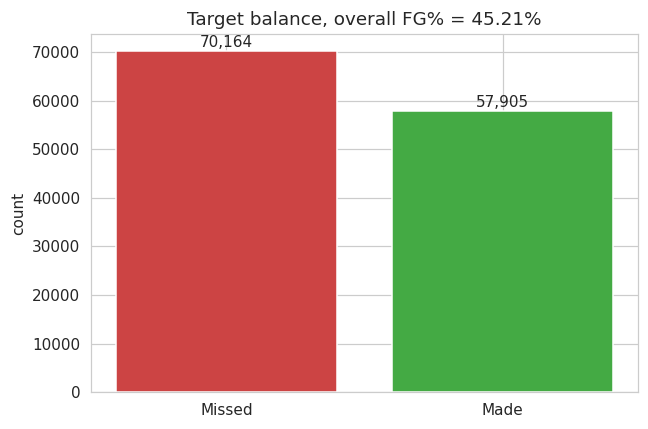

In [ ]:
# 45/55 split, mild imbalance, no resampling needed
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["FGM"].value_counts().sort_index()
ax.bar(["Missed", "Made"], counts.values, color=["#cc4444", "#44aa44"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 800, f"{v:,}", ha="center")
ax.set_ylabel("count")
ax.set_title(f"Target balance, overall FG% = {overall_fgpct:.2f}%")
plt.tight_layout()
plt.savefig("figures/class_balance.png")
plt.show()

### feature distributions

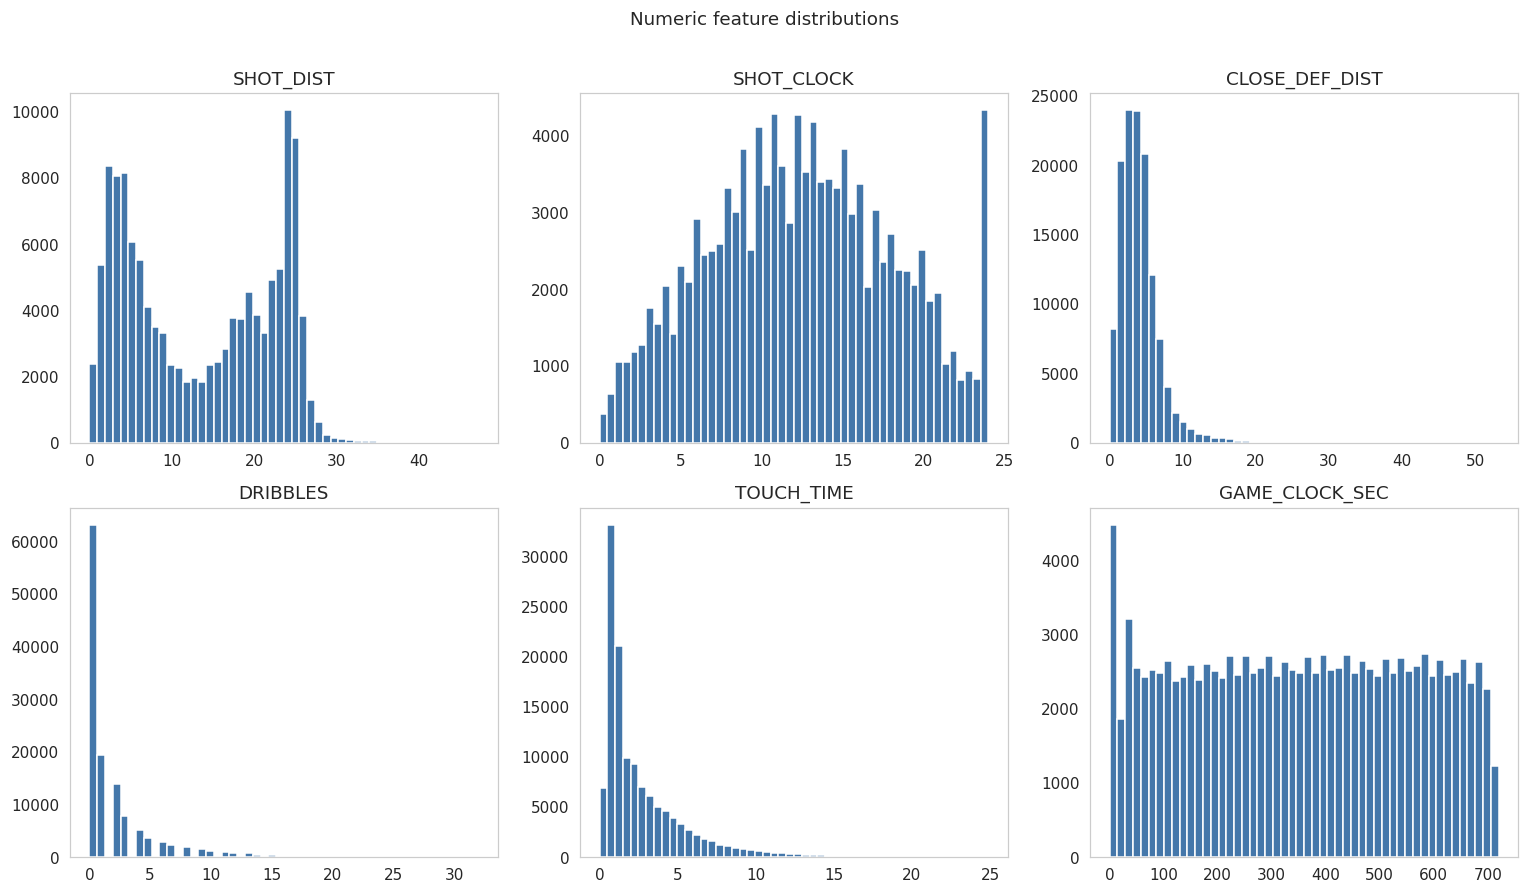

In [ ]:
# Distributions help spot skewness and outliers before modeling
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, num_cols):
    df[col].dropna().hist(bins=50, ax=ax, color="#4477aa", edgecolor="white")
    ax.set_title(col)
    ax.grid(False)
plt.suptitle("Numeric feature distributions", y=1.01)
plt.tight_layout()
plt.savefig("figures/numeric_distributions.png")
plt.show()


### FG% as a function of each feature

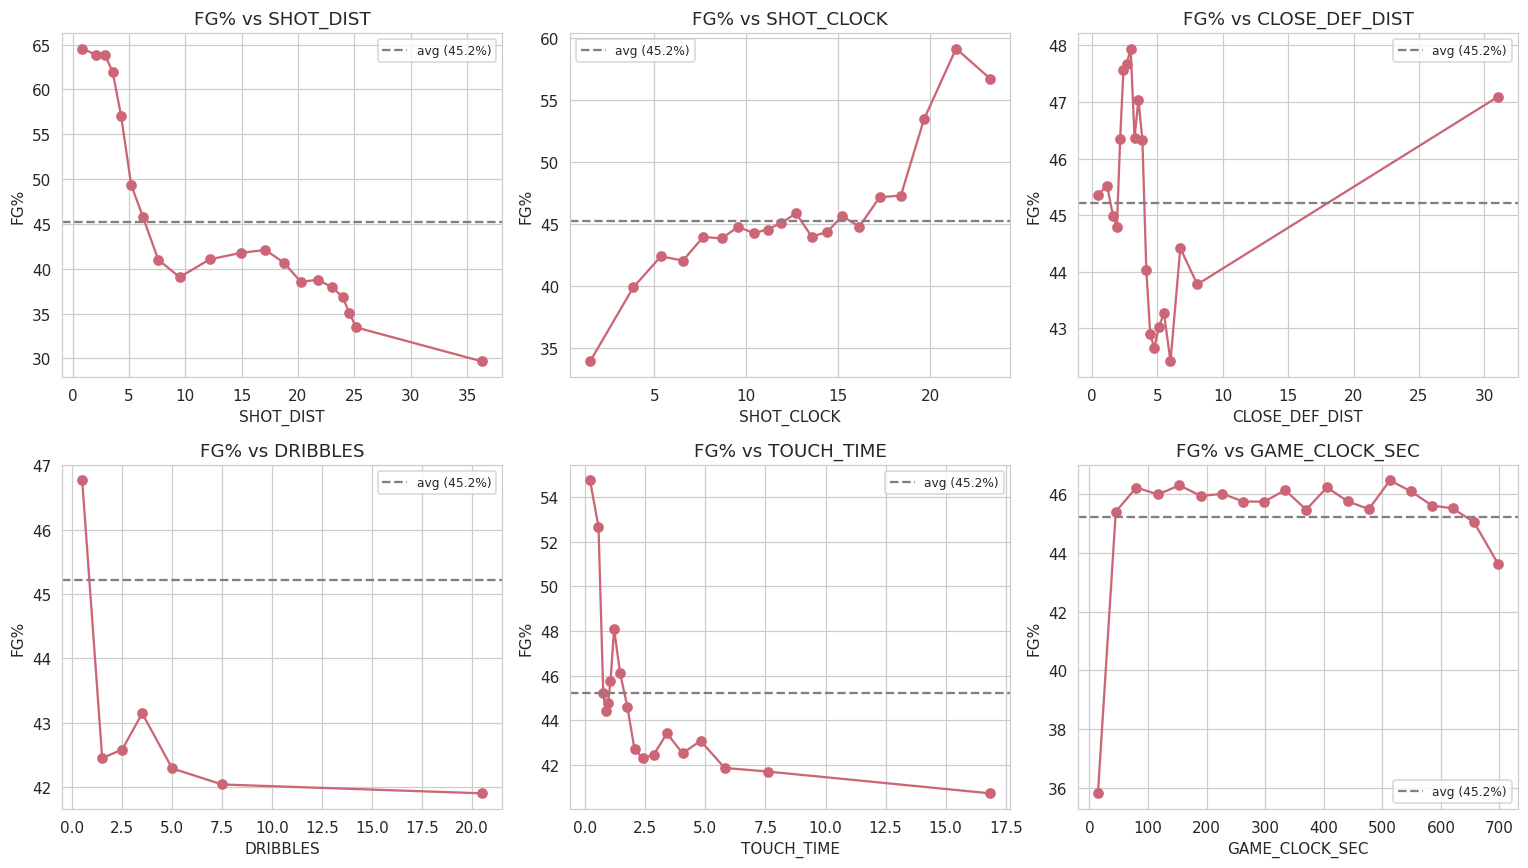

In [ ]:
# Flat line = no signal, slope/curve = predictive
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, num_cols):
    sub  = df[[col, "FGM"]].dropna()
    cuts = pd.qcut(sub[col], q=20, duplicates="drop")
    g    = sub.groupby(cuts, observed=True)["FGM"].agg(["mean", "count"])
    bin_centers = [iv.mid for iv in g.index]
    ax.plot(bin_centers, g["mean"] * 100, marker="o", color="#cc6677")
    ax.axhline(overall_fgpct, ls="--", color="gray", label=f"avg ({overall_fgpct:.1f}%)")
    ax.set_title(f"FG% vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("FG%")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/fgpct_by_feature.png")
plt.show()

### FG% by period

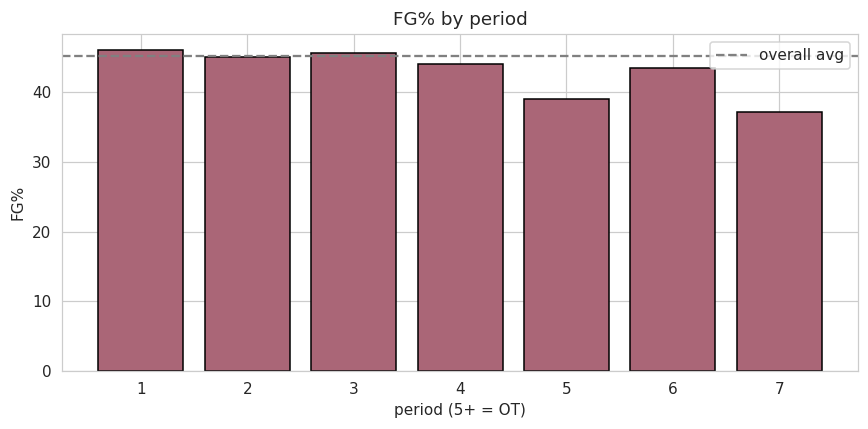

         mean  count
PERIOD              
1       0.461  33961
2       0.451  31651
3       0.457  32211
4       0.440  29123
5       0.390    912
6       0.435    168
7       0.372     43


In [ ]:
# FG% drops in overtime, fatigue matters more than elevated stakes
period_fg = df.groupby("PERIOD")["FGM"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(period_fg.index, period_fg["mean"] * 100, color="#aa6677", edgecolor="black")
ax.axhline(overall_fgpct, ls="--", color="gray", label="overall avg")
ax.set_xlabel("period (5+ = OT)")
ax.set_ylabel("FG%")
ax.set_title("FG% by period")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fgpct_by_period.png")
plt.show()
print(period_fg.round(3))


### correlation matrix

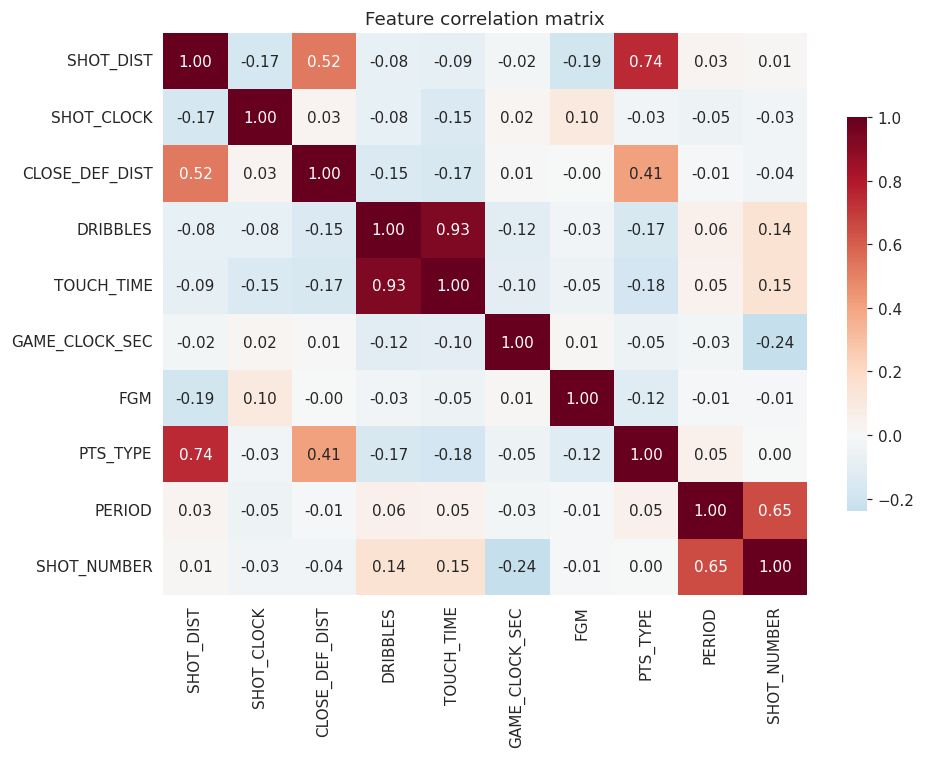

Correlation with FGM (sorted):
SHOT_DIST        -0.192
PTS_TYPE         -0.121
TOUCH_TIME       -0.047
DRIBBLES         -0.034
PERIOD           -0.014
SHOT_NUMBER      -0.008
CLOSE_DEF_DIST   -0.001
GAME_CLOCK_SEC    0.011
SHOT_CLOCK        0.097
Name: FGM, dtype: float64


In [ ]:
# CLOSE_DEF_DIST has near-zero correlation with FGM which seems wrong
# Open shots tend to be long shots which are harder, so contrasting effect
# Tree models handle this through conditional splits, confirmed later with SHAP
corr_cols = num_cols + ["FGM", "PTS_TYPE", "PERIOD", "SHOT_NUMBER"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("figures/correlation.png")
plt.show()

print("Correlation with FGM (sorted):")
print(corr["FGM"].drop("FGM").sort_values().round(3))

## 4. PCA and t-SNE

PCA shows intrinsic dimensionality and what combinations of features carry the most variance.
t-SNE reveals local cluster structure but is slow so we subsample to 4k points.

Key finding: data clusters by shot type and context, not by outcome.
Made and missed shots are completely intermixed, confirming this is a probabilistic
estimation problem more than a clean classification task.


In [ ]:
features_for_dim = num_cols + ["PTS_TYPE", "PERIOD", "SHOT_NUMBER"]
X_dim = df[features_for_dim].dropna()
y_dim = df.loc[X_dim.index, "FGM"].values
print("using", len(X_dim), "rows")

# Standardize so no feature dominates due to scale
scaler_dim = StandardScaler()
X_scaled = scaler_dim.fit_transform(X_dim)

using 122502 rows


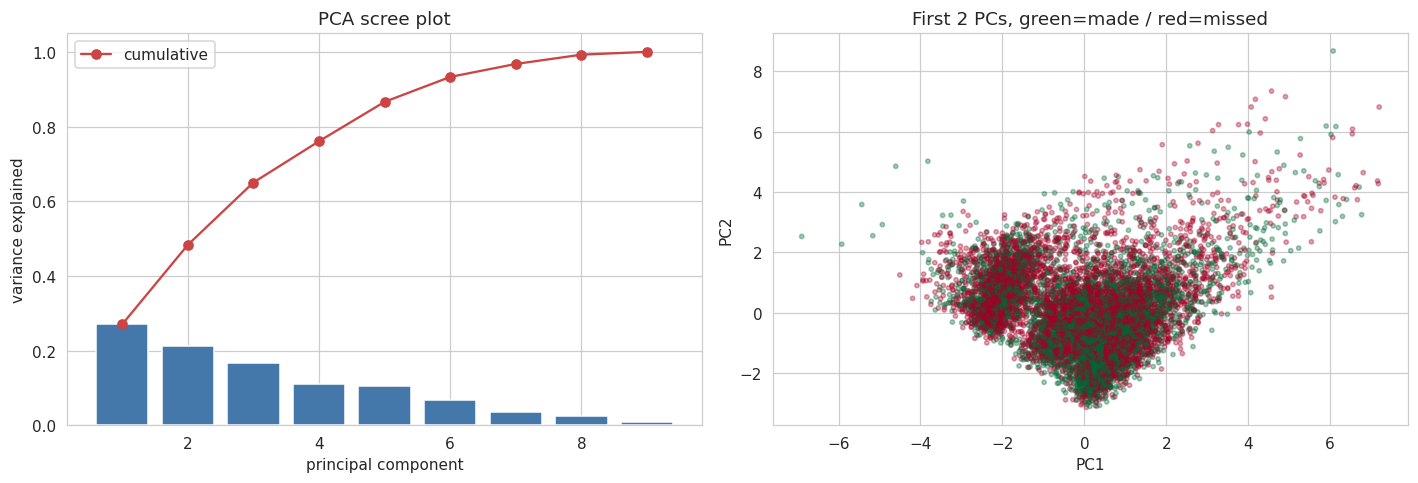

first 2 PCs explain 48.3% of variance


In [ ]:
pca = PCA(n_components=len(features_for_dim))
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(range(1, len(features_for_dim) + 1), pca.explained_variance_ratio_, color="#4477aa")
axes[0].plot(range(1, len(features_for_dim) + 1),
             np.cumsum(pca.explained_variance_ratio_),
             marker="o", color="#cc4444", label="cumulative")
axes[0].set_xlabel("principal component")
axes[0].set_ylabel("variance explained")
axes[0].set_title("PCA scree plot")
axes[0].legend()

# If made/missed were separable we would see distinct clusters, instead complete mixing
rng = np.random.RandomState(SEED)
samp = rng.choice(len(X_pca), size=10000, replace=False)
axes[1].scatter(X_pca[samp, 0], X_pca[samp, 1],
                c=y_dim[samp], cmap="RdYlGn", alpha=0.35, s=8)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("First 2 PCs, green=made / red=missed")
plt.tight_layout()
plt.savefig("figures/pca.png")
plt.show()

pct2 = pca.explained_variance_ratio_[:2].sum() * 100
print(f"first 2 PCs explain {pct2:.1f}% of variance")

### t-SNE (runs around 30 seconds)

running t-SNE...
done


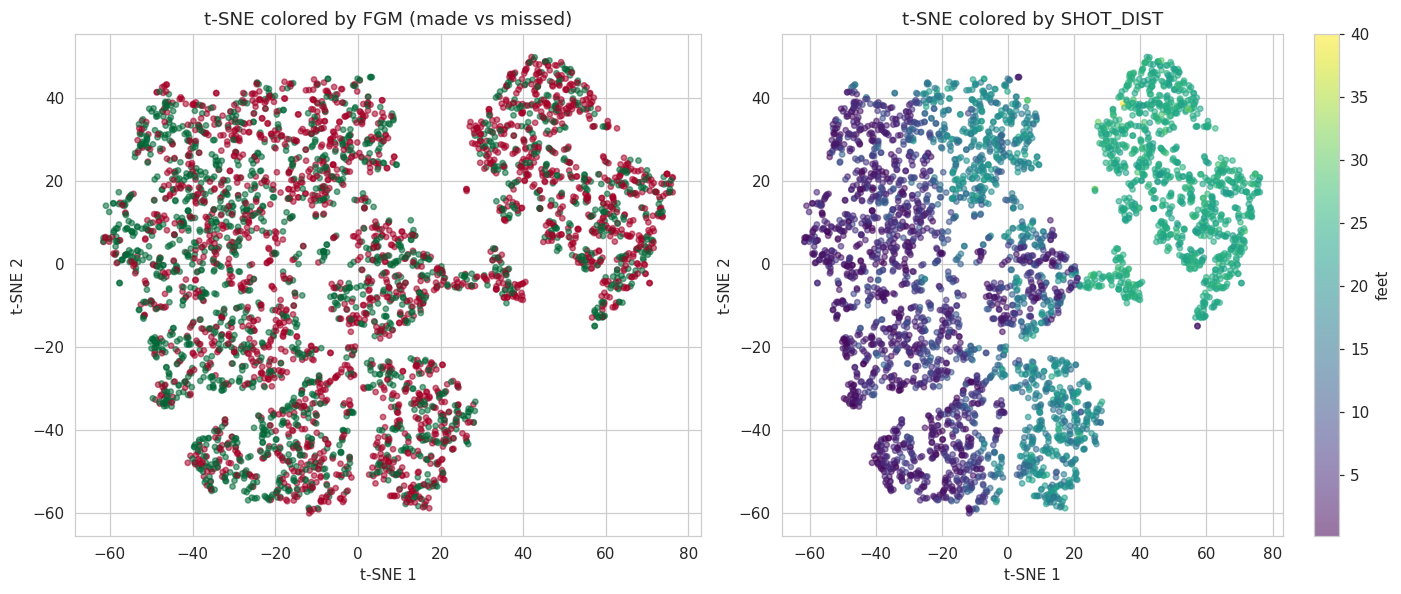

In [ ]:
N_TSNE   = 4000  # subsample for speed, t-SNE scales roughly quadratically
sub_idx  = rng.choice(len(X_scaled), size=N_TSNE, replace=False)
X_sub    = X_scaled[sub_idx]
y_sub    = y_dim[sub_idx]
dist_sub = df.loc[X_dim.index[sub_idx], "SHOT_DIST"].values

print("running t-SNE...")
tsne   = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca")
X_tsne = tsne.fit_transform(X_sub)
print("done")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: colored by outcome, no clear separation at all!
axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sub, cmap="RdYlGn", alpha=0.55, s=12)
axes[0].set_title("t-SNE colored by FGM (made vs missed)")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

# Right: colored by shot distance, clear clusters showing t-SNE organized by shot type
sc = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=dist_sub, cmap="viridis", alpha=0.55, s=12)
axes[1].set_title("t-SNE colored by SHOT_DIST")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
plt.colorbar(sc, ax=axes[1], label="feet")
plt.tight_layout()
plt.savefig("figures/tsne.png")
plt.show()

## 5. Modeling setup

Standard 80/20 stratified split. Player and defender IDs are target encoded using
out-of-fold encoding to prevent leakage: each fold's encoding is computed from the
other folds only, then smoothed toward the league mean.

Smoothing: (n * player_mean + 50 * league_mean) / (n + 50)


In [ ]:
# Load the fully engineered dataset
df = pd.read_csv("data/modeling.csv")

# Define feature groups used throughout the rest of the notebook
NUMERIC = [
    "SHOT_DIST", "SHOT_CLOCK", "CLOSE_DEF_DIST",
    "LOG_DRIBBLES", "LOG_TOUCH_TIME", "GAME_CLOCK_SEC",
    "PTS_TYPE", "PERIOD", "SHOT_NUMBER",
    "SHOT_CLOCK_FRAC", "DEF_DIST_PER_SHOT_DIST"
]
BINARY = [
    "IS_CATCH_AND_SHOOT", "IS_LATE_CLOCK", "IS_BUZZER_BEATER",
    "IS_HOME", "IS_OPEN", "SHOT_CLOCK_MISSING"
]
CATEGORICAL   = ["SHOT_ZONE"]
TARGET_ENCODE = ["player_id", "CLOSEST_DEFENDER_PLAYER_ID"]

X = df[NUMERIC + BINARY + CATEGORICAL + TARGET_ENCODE].copy()
y = df["FGM"].copy()

# Stratify to preserve the 45/55 class balance in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
print("train:", len(X_train), "  test:", len(X_test))

train: 102455   test: 25614


In [ ]:
# Smoothed mean with Bayesian shrinkage toward the global prior
# alpha=50 means a player needs 50+ shots before their mean is trusted over league average
def smoothed_mean(vals, target, prior, alpha=50):
    g = pd.DataFrame({"v": vals, "t": target}).groupby("v")["t"]
    counts = g.count()
    means  = g.mean()
    return (counts * means + alpha * prior) / (counts + alpha)

def oof_encode(values, target, n_folds=5, alpha=50):
    # Each fold's encoding is computed only from the other folds, no leakage
    prior   = target.mean()
    encoded = pd.Series(prior, index=values.index, dtype=float)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    for tr_idx, val_idx in kf.split(values):
        enc_map = smoothed_mean(values.iloc[tr_idx], target.iloc[tr_idx], prior, alpha)
        encoded.iloc[val_idx] = values.iloc[val_idx].map(enc_map).fillna(prior)
    return encoded

def encode_test(test_vals, train_vals, train_target, alpha=50):
    prior   = train_target.mean()
    enc_map = smoothed_mean(train_vals, train_target, prior, alpha)
    return test_vals.map(enc_map).fillna(prior)

print("Applying OOF target encoding...")
for col in TARGET_ENCODE:
    X_train[col + "_FG_ENC"] = oof_encode(X_train[col], y_train).values
    X_test[col + "_FG_ENC"]  = encode_test(X_test[col], X_train[col], y_train).values

X_train.drop(columns=TARGET_ENCODE, inplace=True)
X_test.drop(columns=TARGET_ENCODE, inplace=True)
NUMERIC_FINAL = NUMERIC + [c + "_FG_ENC" for c in TARGET_ENCODE]
print("final feature count:", X_train.shape[1])


Applying OOF target encoding...
final feature count: 20


In [ ]:
# Linear models and MLP need scaling, tree models do not
scaler_pipe = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FINAL),
    ("bin", "passthrough", BINARY),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), CATEGORICAL),
])
trees_pipe = ColumnTransformer([
    ("num", "passthrough", NUMERIC_FINAL),
    ("bin", "passthrough", BINARY),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), CATEGORICAL),
])

X_train_scaled = scaler_pipe.fit_transform(X_train)
X_test_scaled  = scaler_pipe.transform(X_test)
X_train_trees  = trees_pipe.fit_transform(X_train)
X_test_trees   = trees_pipe.transform(X_test)

ohe_cats      = scaler_pipe.named_transformers_["cat"]
feature_names = NUMERIC_FINAL + BINARY + list(ohe_cats.get_feature_names_out(CATEGORICAL))
joblib.dump(feature_names, "data/feature_names.joblib")
print("matrix shape:", X_train_scaled.shape)

matrix shape: (102455, 24)


## 6. Baseline models (roughly 2 min)

Five model families at default or near-default hyperparameters.
Logistic regression is the linear baseline. Tree-based models typically win on tabular data.
MLP is the neural network baseline. All compared against a naive model that always
predicts the league average probability.

Primary metrics are log loss and Brier score since we care about probability quality.


In [ ]:
baseline_results = {}
baseline_probas  = {}

# Linear and MLP get scaled inputs, tree models get raw numeric
model_configs = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=SEED),
        X_train_scaled, X_test_scaled
    ),
    "Random Forest": (
        RandomForestClassifier(n_estimators=100, max_depth=12,
                               min_samples_leaf=20, n_jobs=-1, random_state=SEED),
        X_train_trees, X_test_trees
    ),
    "XGBoost": (
        XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                      eval_metric="logloss", random_state=SEED, n_jobs=-1),
        X_train_trees, X_test_trees
    ),
    "LightGBM": (
        LGBMClassifier(n_estimators=200, learning_rate=0.1,
                       random_state=SEED, n_jobs=-1, verbose=-1),
        X_train_trees, X_test_trees
    ),
    "MLP": (
        MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=40,
                      early_stopping=True, random_state=SEED),
        X_train_scaled, X_test_scaled
    ),
}

for name, (model, Xtr, Xte) in model_configs.items():
    t0 = time.time()
    model.fit(Xtr, y_train)
    proba = model.predict_proba(Xte)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    baseline_probas[name]  = proba
    baseline_results[name] = {
        "Accuracy": accuracy_score(y_test, pred),
        "LogLoss":  log_loss(y_test, proba),
        "Brier":    brier_score_loss(y_test, proba),
        "AUC":      roc_auc_score(y_test, proba),
    }
    print(f"{name:<22}  AUC={baseline_results[name]['AUC']:.4f}  "
          f"LogLoss={baseline_results[name]['LogLoss']:.4f}  ({time.time()-t0:.1f}s)")

# Always-predict-average baseline as the floor
prior_prob = float(y_train.mean())
naive_p = np.full(len(y_test), prior_prob)
baseline_results["Naive (always avg)"] = {
    "Accuracy": accuracy_score(y_test, (naive_p >= 0.5).astype(int)),
    "LogLoss":  log_loss(y_test, naive_p),
    "Brier":    brier_score_loss(y_test, naive_p),
    "AUC":      0.5,
}


Logistic Regression     AUC=0.6342  LogLoss=0.6546  (0.9s)
Random Forest           AUC=0.6382  LogLoss=0.6486  (14.0s)
XGBoost                 AUC=0.6334  LogLoss=0.6497  (3.8s)
LightGBM                AUC=0.6349  LogLoss=0.6495  (2.3s)
MLP                     AUC=0.6350  LogLoss=0.6525  (9.1s)


In [ ]:
# Sort by AUC so the best model is at the top
results_df = pd.DataFrame(baseline_results).T.round(4).sort_values("AUC", ascending=False)
print("Baseline results:")
print()
print(results_df.to_string())


Baseline results:

                     Accuracy  LogLoss   Brier     AUC
Random Forest          0.6186   0.6486  0.2292  0.6382
MLP                    0.6180   0.6525  0.2307  0.6350
LightGBM               0.6161   0.6495  0.2297  0.6349
Logistic Regression    0.6155   0.6546  0.2315  0.6342
XGBoost                0.6169   0.6497  0.2298  0.6334
Naive (always avg)     0.5479   0.6886  0.2477  0.5000


## 7. Evaluation visualizations

### roc curves

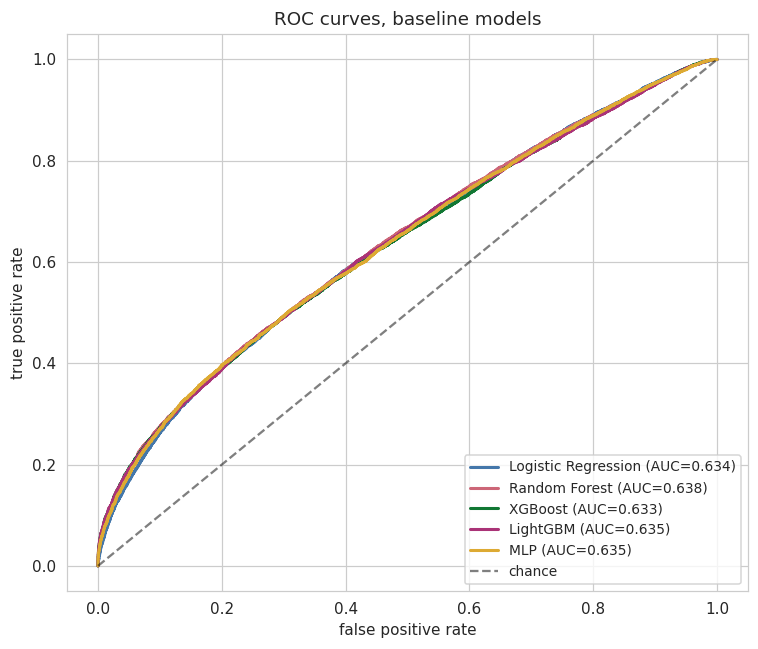

In [ ]:
# All five models overlap almost perfectly, we are near the information ceiling
colors = ["#4477aa", "#cc6677", "#117733", "#aa3377", "#ddaa33"]

fig, ax = plt.subplots(figsize=(7, 6))
for (name, p), c in zip(baseline_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, color=c, lw=2, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="chance")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curves, baseline models")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("figures/roc.png")
plt.show()


### calibration curves

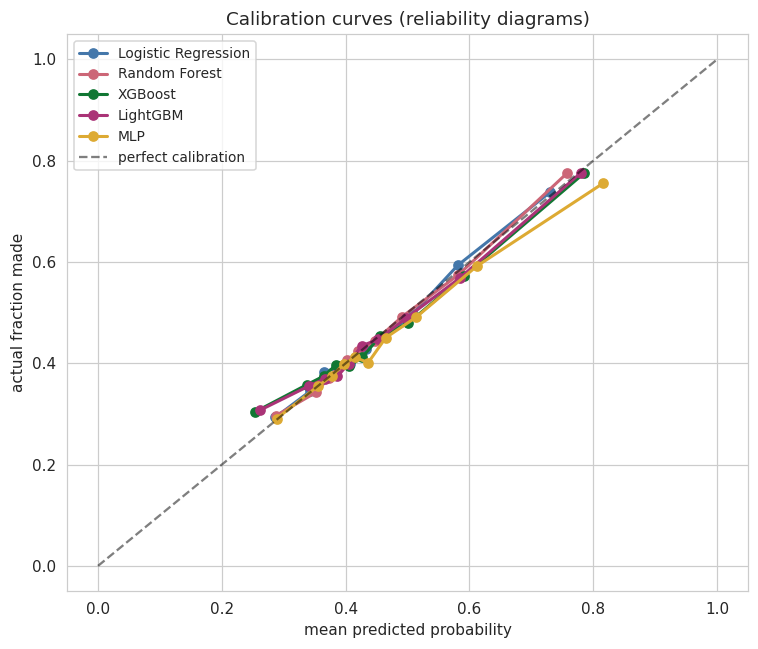

In [ ]:
# Calibration shows whether predicted probabilities match actual frequencies
# Well-calibrated = when model says 60%, roughly 60% of those shots go in
fig, ax = plt.subplots(figsize=(7, 6))
for (name, p), c in zip(baseline_probas.items(), colors):
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", color=c, lw=2, label=name)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfect calibration")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("actual fraction made")
ax.set_title("Calibration curves (reliability diagrams)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("figures/calibration.png")
plt.show()

### confusion matrices

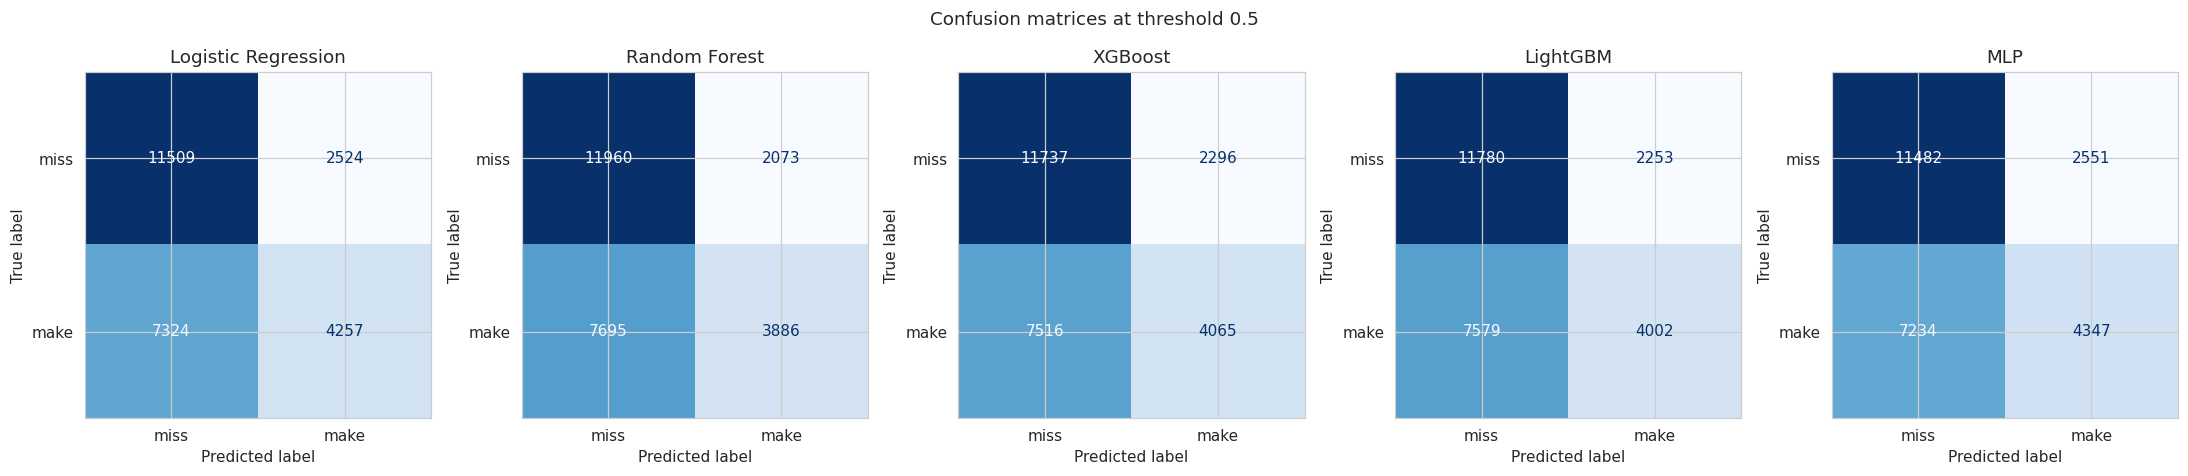

In [ ]:
# Models predict miss far more often than actual rate due to probabilities clustering near 0.45
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, p) in zip(axes, baseline_probas.items()):
    pred = (p >= 0.5).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=["miss", "make"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.suptitle("Confusion matrices at threshold 0.5", y=1.02)
plt.tight_layout()
plt.savefig("figures/confusion.png", bbox_inches="tight")
plt.show()

## 8. Hyperparameter tuning (roughly 5 min)

Randomized search over 6 configurations with 3-fold cross-validation scored on negative log loss.
Random Forest excluded since boosted models typically win after tuning on tabular data.

Parameter reasoning:
- n_estimators: more rounds help until diminishing returns around 300
- max_depth / num_leaves: controls complexity and feature interaction depth
- learning_rate: smaller usually generalizes better but needs more rounds
- subsample / colsample_bytree: row and feature sampling act as regularization
- reg_lambda: L2 weight penalty against overfitting


In [ ]:
# Helper to randomly sample one config from a parameter grid
def sample_config(grid, rng_obj):
    return {k: rng_obj.choice(v) for k, v in grid.items()}

def run_cv(model_cls, params, fixed_kw, X, y, splitter):
    # Returns mean log loss across folds for the given config
    losses = []
    for tr_idx, val_idx in splitter.split(X, y):
        m = model_cls(**params, **fixed_kw)
        m.fit(X[tr_idx], y[tr_idx])
        proba = m.predict_proba(X[val_idx])[:, 1]
        losses.append(log_loss(y[val_idx], proba))
    return float(np.mean(losses))

# 3 folds is enough here given 100k+ training rows
cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)


In [ ]:
# XGBoost randomized search over 6 configurations
xgb_grid = {
    "n_estimators":     [150, 200, 250],
    "max_depth":        [4, 5, 6, 7],
    "learning_rate":    [0.05, 0.08, 0.1],
    "min_child_weight": [1, 5, 10],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda":       [0.5, 1.0, 3.0],
}

xgb_history = []
rng_s = random.Random(SEED)

print("XGBoost search (6 configs x 3 folds):")
for i in range(6):
    cfg   = sample_config(xgb_grid, rng_s)
    score = run_cv(XGBClassifier, cfg,
                   {"eval_metric": "logloss", "random_state": SEED,
                    "n_jobs": -1, "tree_method": "hist"},
                   X_train_trees, y_train.values, cv_splitter)
    xgb_history.append({"params": cfg, "cv_logloss": score})
    print(f"  config {i+1}/6  logloss={score:.4f}")

xgb_best = min(xgb_history, key=lambda r: r["cv_logloss"])
print()
print("best logloss:", round(xgb_best["cv_logloss"], 4))
print("best params:", xgb_best["params"])


XGBoost search (6 configs x 3 folds):
  config 1/6  logloss=0.6465
  config 2/6  logloss=0.6469
  config 3/6  logloss=0.6466
  config 4/6  logloss=0.6486
  config 5/6  logloss=0.6527
  config 6/6  logloss=0.6467

best logloss: 0.6465
best params: {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 10, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_lambda': 0.5}


In [ ]:
# LightGBM search, num_leaves is the main complexity control here
lgb_grid = {
    "n_estimators":      [150, 200, 250],
    "num_leaves":        [15, 31, 63],
    "max_depth":         [-1, 6, 8],
    "learning_rate":     [0.05, 0.08, 0.1],
    "min_child_samples": [10, 20, 50],
    "subsample":         [0.8, 1.0],
    "colsample_bytree":  [0.8, 1.0],
    "reg_lambda":        [0.5, 1.0, 3.0],
}

lgb_history = []
rng_s2 = random.Random(SEED)

print("LightGBM search (6 configs x 3 folds):")
for i in range(6):
    cfg   = sample_config(lgb_grid, rng_s2)
    score = run_cv(LGBMClassifier, cfg,
                   {"random_state": SEED, "n_jobs": -1, "verbose": -1},
                   X_train_trees, y_train.values, cv_splitter)
    lgb_history.append({"params": cfg, "cv_logloss": score})
    print(f"  config {i+1}/6  logloss={score:.4f}")

lgb_best = min(lgb_history, key=lambda r: r["cv_logloss"])
print()
print("best logloss:", round(lgb_best["cv_logloss"], 4))
print("best params:", lgb_best["params"])


LightGBM search (6 configs x 3 folds):
  config 1/6  logloss=0.6471
  config 2/6  logloss=0.6473
  config 3/6  logloss=0.6464
  config 4/6  logloss=0.6511
  config 5/6  logloss=0.6474
  config 6/6  logloss=0.6464

best logloss: 0.6464
best params: {'n_estimators': 150, 'num_leaves': 15, 'max_depth': 6, 'learning_rate': 0.05, 'min_child_samples': 20, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_lambda': 0.5}


### fit best configs on full training data

In [ ]:
# Retrain with best params on the full training data
xgb_tuned = XGBClassifier(**xgb_best["params"], eval_metric="logloss",
                           random_state=SEED, n_jobs=-1, tree_method="hist")
xgb_tuned.fit(X_train_trees, y_train)
xgb_proba = xgb_tuned.predict_proba(X_test_trees)[:, 1]

lgb_tuned = LGBMClassifier(**lgb_best["params"], random_state=SEED, n_jobs=-1, verbose=-1)
lgb_tuned.fit(X_train_trees, y_train)
lgb_proba = lgb_tuned.predict_proba(X_test_trees)[:, 1]

# Save models to disk so SHAP and player analysis can reload them if needed
joblib.dump(xgb_tuned, "data/xgb_best.joblib")
joblib.dump(lgb_tuned, "data/lgb_best.joblib")

def get_metrics(y_true, proba):
    pred = (proba >= 0.5).astype(int)
    return {"Accuracy": accuracy_score(y_true, pred),
            "LogLoss":  log_loss(y_true, proba),
            "Brier":    brier_score_loss(y_true, proba),
            "AUC":      roc_auc_score(y_true, proba)}

tuned_results = {
    "XGBoost (tuned)":  get_metrics(y_test, xgb_proba),
    "LightGBM (tuned)": get_metrics(y_test, lgb_proba),
}
print("Tuned results on test set:")
print()
print(pd.DataFrame(tuned_results).T.round(4).to_string())


Tuned results on test set:

                  Accuracy  LogLoss   Brier     AUC
XGBoost (tuned)     0.6197   0.6478  0.2289  0.6389
LightGBM (tuned)    0.6201   0.6476  0.2288  0.6392


## 9. Threshold analysis

The default 0.5 threshold maximizes accuracy but recall is very low since most
predicted probabilities cluster near 0.45.

Since calibration is good, the better framing is to report the probability directly
as an expected FG% rather than forcing a binary decision. This is how real NBA
analytics tools like Second Spectrum handle shot quality.


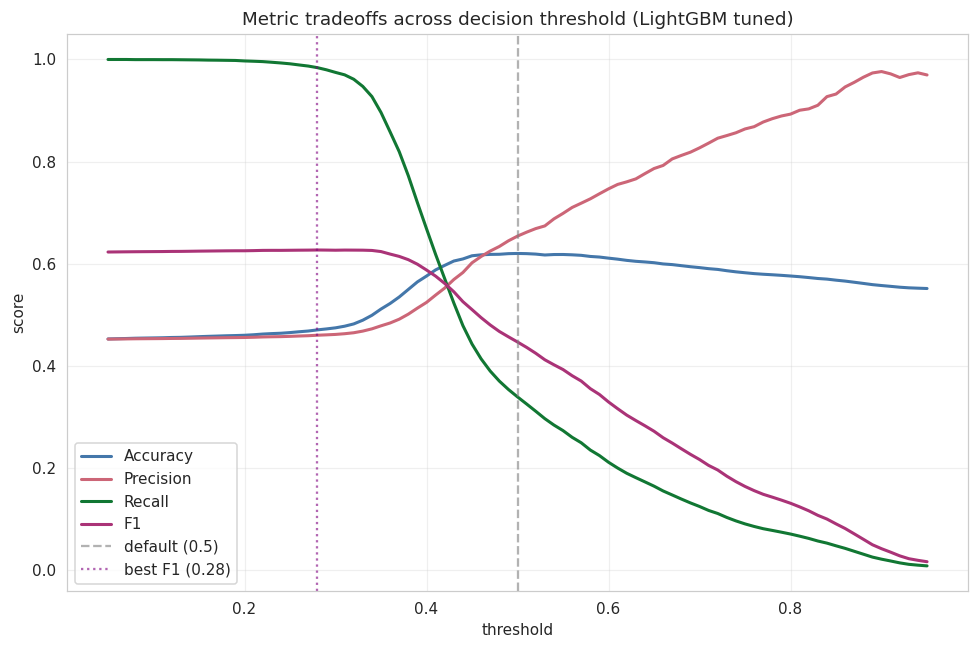

best accuracy at 0.5: 0.6201
best F1 at 0.28: 0.6269


In [ ]:
# Sweep thresholds and record all four metrics at each point
thresholds = np.linspace(0.05, 0.95, 91)
acc_vals, prec_vals, rec_vals, f1_vals = [], [], [], []

for t in thresholds:
    preds = (lgb_proba >= t).astype(int)
    acc_vals.append(accuracy_score(y_test, preds))
    prec_vals.append(precision_score(y_test, preds, zero_division=0))
    rec_vals.append(recall_score(y_test, preds, zero_division=0))
    f1_vals.append(f1_score(y_test, preds, zero_division=0))

acc_vals  = np.array(acc_vals)
f1_vals   = np.array(f1_vals)
best_f1_t = thresholds[np.argmax(f1_vals)]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(thresholds, acc_vals,  label="Accuracy",  color="#4477aa", lw=2)
ax.plot(thresholds, prec_vals, label="Precision", color="#cc6677", lw=2)
ax.plot(thresholds, rec_vals,  label="Recall",    color="#117733", lw=2)
ax.plot(thresholds, f1_vals,   label="F1",        color="#aa3377", lw=2)
ax.axvline(0.5, color="gray", ls="--", alpha=0.6, label="default (0.5)")
ax.axvline(best_f1_t, color="purple", ls=":", alpha=0.6,
           label=f"best F1 ({best_f1_t:.2f})")
ax.set_xlabel("threshold")
ax.set_ylabel("score")
ax.set_title("Metric tradeoffs across decision threshold (LightGBM tuned)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/threshold.png")
plt.show()

print(f"best accuracy at 0.5: {acc_vals[45]:.4f}")
print(f"best F1 at {best_f1_t:.2f}: {f1_vals.max():.4f}")


## 10. SHAP explainability

SHAP assigns each feature a contribution value per prediction showing how much it
pushed the predicted probability up or down for that specific shot.

Key finding: DEF_DIST_PER_SHOT_DIST, the engineered ratio, ranks first. This resolves
the CLOSE_DEF_DIST paradox from EDA where raw correlation appeared near zero.


In [ ]:
feature_names = joblib.load("data/feature_names.joblib")

rng_shap = np.random.RandomState(SEED)
shap_idx  = rng_shap.choice(len(X_test_trees), size=2000, replace=False)
X_shap    = X_test_trees[shap_idx]

print("Computing SHAP values on 2000 test shots...")
explainer = shap.TreeExplainer(lgb_tuned)
shap_vals = explainer.shap_values(X_shap)
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]  # class 1 = made shot
print("shape:", shap_vals.shape)

Computing SHAP values on 2000 test shots...
shape: (2000, 24)


### feature importance bar chart

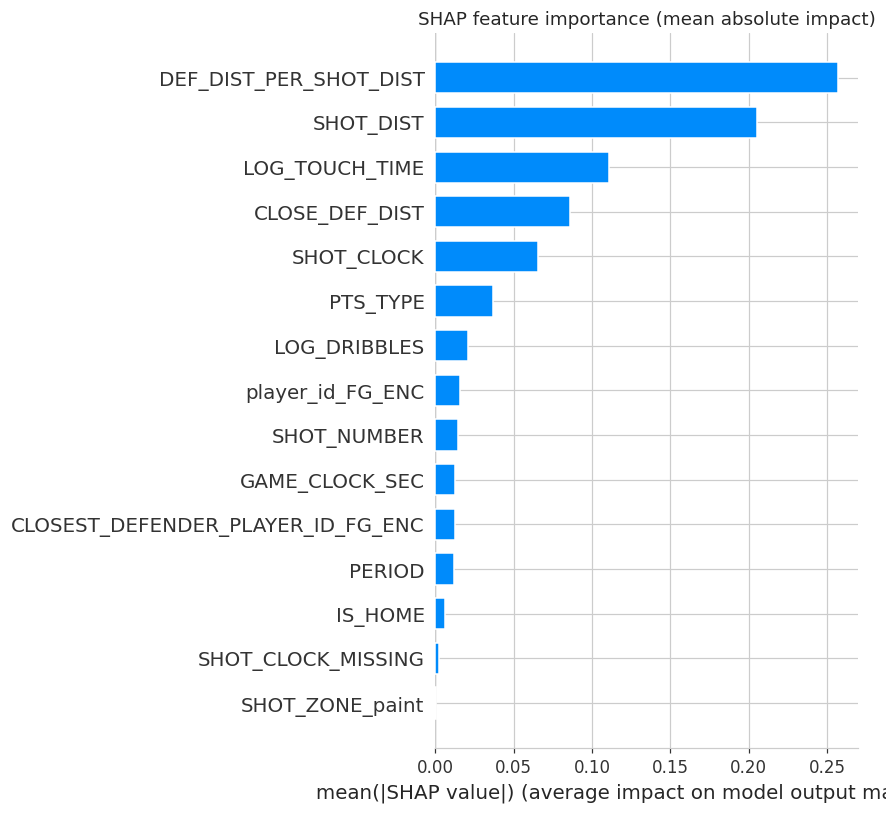

In [ ]:
# Mean absolute SHAP value per feature, more reliable than tree feature importance
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_vals, X_shap, feature_names=feature_names,
                  plot_type="bar", show=False, max_display=15)
plt.title("SHAP feature importance (mean absolute impact)")
plt.tight_layout()
plt.savefig("figures/shap_bar.png", bbox_inches="tight")
plt.show()


### value distribution swarm plot

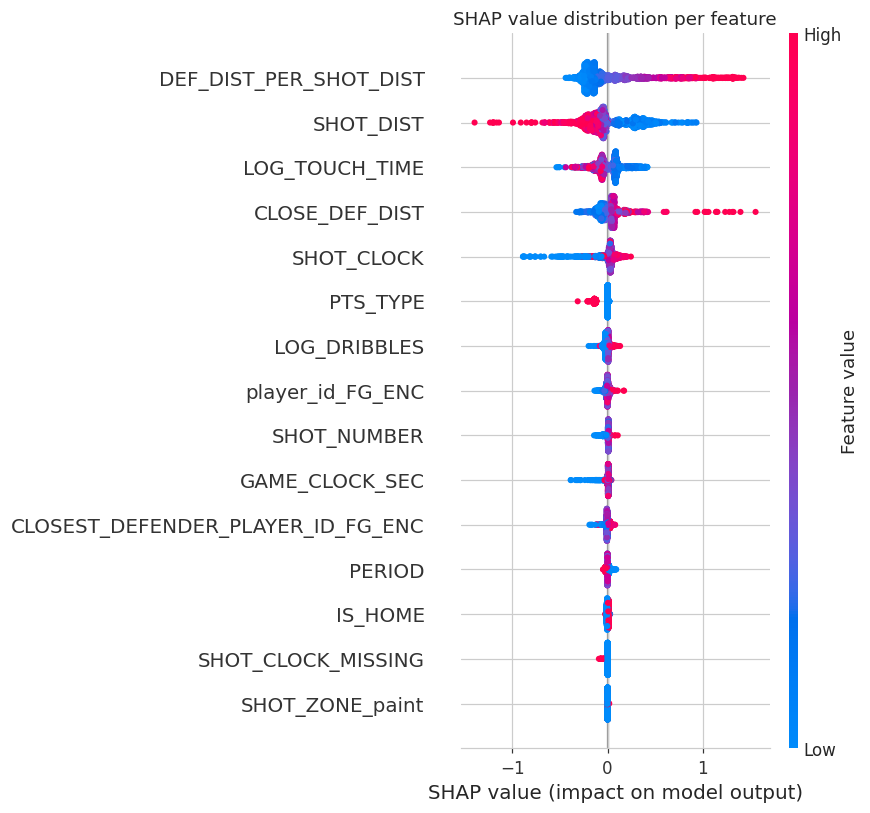

In [ ]:
# Color = feature value (red=high, blue=low), position = SHAP impact
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_vals, X_shap, feature_names=feature_names,
                  show=False, max_display=15)
plt.title("SHAP value distribution per feature")
plt.tight_layout()
plt.savefig("figures/shap_summary.png", bbox_inches="tight")
plt.show()

### dependence plots for top 4 features

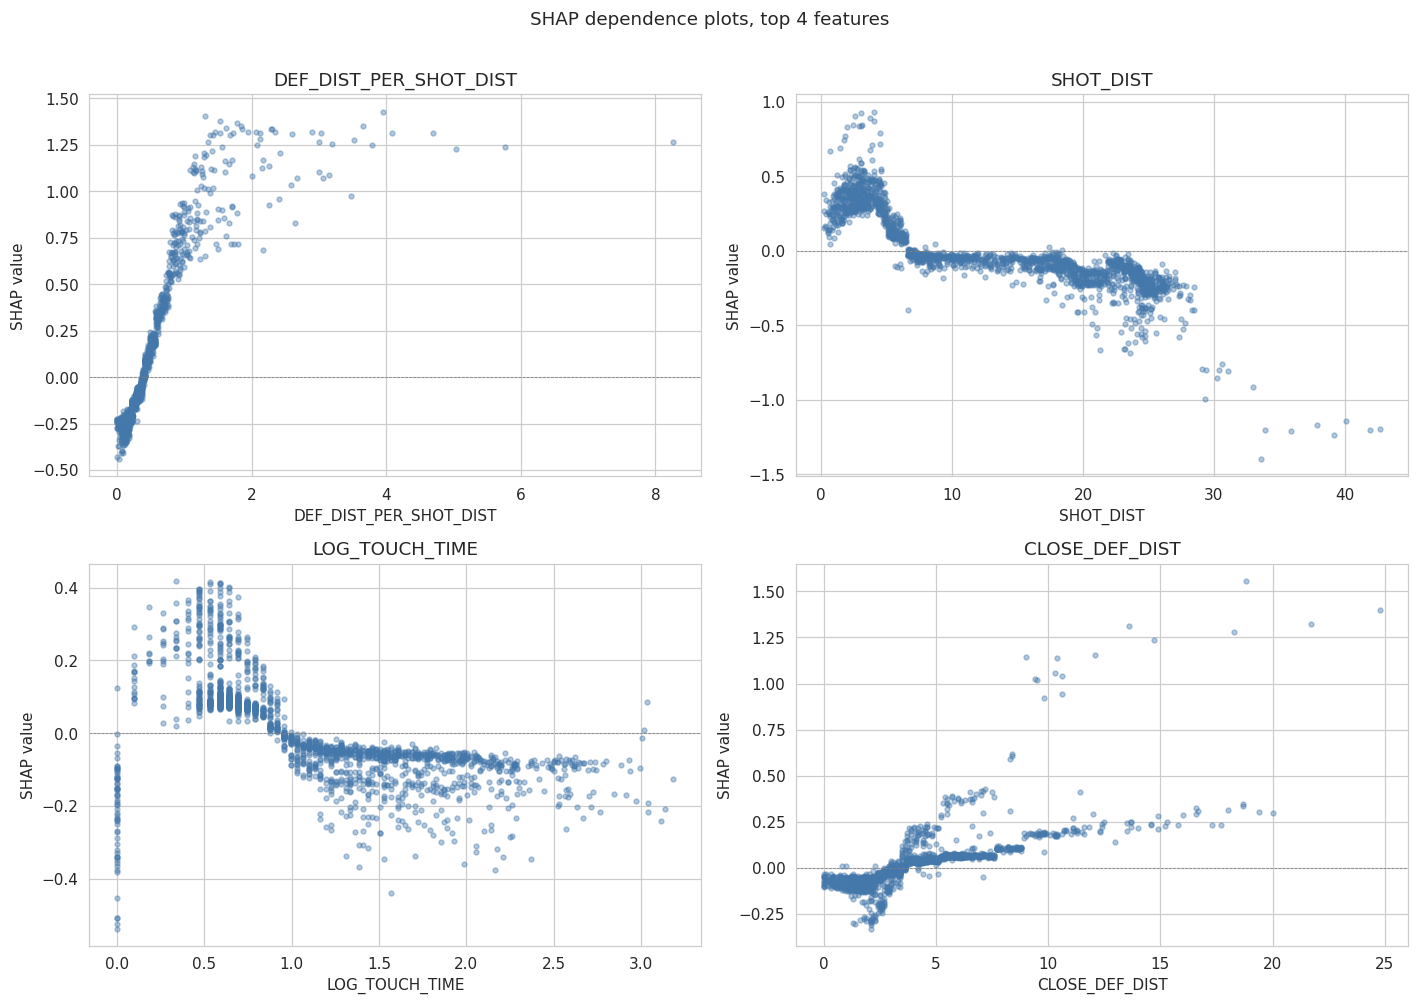

Feature importance (mean |SHAP|):
  DEF_DIST_PER_SHOT_DIST                   0.2569
  SHOT_DIST                                0.2054
  LOG_TOUCH_TIME                           0.1109
  CLOSE_DEF_DIST                           0.0856
  SHOT_CLOCK                               0.0658
  PTS_TYPE                                 0.0367
  LOG_DRIBBLES                             0.0208
  player_id_FG_ENC                         0.0156
  SHOT_NUMBER                              0.0147
  GAME_CLOCK_SEC                           0.0128
  CLOSEST_DEFENDER_PLAYER_ID_FG_ENC        0.0127
  PERIOD                                   0.0116


In [ ]:
mean_abs = np.abs(shap_vals).mean(axis=0)
top4     = np.argsort(mean_abs)[::-1][:4]

# Shows how each feature's impact changes as its value changes
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, fi in zip(axes.flat, top4):
    fname = feature_names[fi]
    ax.scatter(X_shap[:, fi], shap_vals[:, fi], alpha=0.4, s=10, c="#4477aa")
    ax.axhline(0, color="gray", lw=0.5, ls="--")  # above zero = helps make, below = hurts
    ax.set_xlabel(fname)
    ax.set_ylabel("SHAP value")
    ax.set_title(fname)
plt.suptitle("SHAP dependence plots, top 4 features", y=1.01)
plt.tight_layout()
plt.savefig("figures/shap_dependence.png")
plt.show()

print("Feature importance (mean |SHAP|):")
for fname, imp in sorted(zip(feature_names, mean_abs), key=lambda x: -x[1])[:12]:
    print(f"  {fname:<40} {imp:.4f}")


## 11. Player shot-making analysis

A separate model trained without player identity so predictions represent
what an average player would shoot in the same situation.

actual FG% minus expected FG% per player measures shooting skill above expectations,
same logic as expected goals models in soccer analytics.


In [ ]:
df2 = pd.read_csv("data/modeling.csv")

# No player encoding here! player skill needs to show up in the residual
X2 = df2[NUMERIC + BINARY + CATEGORICAL + ["CLOSEST_DEFENDER_PLAYER_ID"]].copy()
y2 = df2["FGM"].copy()
player_ids   = df2["player_id"]
player_names = df2["player_name"]

X2_tr, X2_te, y2_tr, y2_te, id_tr, id_te, nm_tr, nm_te = train_test_split(
    X2, y2, player_ids, player_names,
    test_size=0.2, random_state=SEED, stratify=y2)
print("train:", len(X2_tr), "  test:", len(X2_te))

train: 102455   test: 25614


In [ ]:
# Defender encoding is still fine, we are measuring shooter skill not defender quality
prior2   = y2_tr.mean()
def_map  = smoothed_mean(X2_tr["CLOSEST_DEFENDER_PLAYER_ID"], y2_tr, prior2)
X2_tr["DEFENDER_ENC"] = oof_encode(X2_tr["CLOSEST_DEFENDER_PLAYER_ID"], y2_tr).values
X2_te["DEFENDER_ENC"] = X2_te["CLOSEST_DEFENDER_PLAYER_ID"].map(def_map).fillna(prior2)
X2_tr.drop(columns=["CLOSEST_DEFENDER_PLAYER_ID"], inplace=True)
X2_te.drop(columns=["CLOSEST_DEFENDER_PLAYER_ID"], inplace=True)

pre2 = ColumnTransformer([
    ("num", "passthrough", NUMERIC + ["DEFENDER_ENC"]),
    ("bin", "passthrough", BINARY),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), CATEGORICAL),
])
X2_tr_arr = pre2.fit_transform(X2_tr)
X2_te_arr = pre2.transform(X2_te)

sit_model = LGBMClassifier(n_estimators=200, num_leaves=15, max_depth=6,
                            learning_rate=0.05, min_child_samples=20,
                            random_state=SEED, n_jobs=-1, verbose=-1)
sit_model.fit(X2_tr_arr, y2_tr)
print("situation model trained")

situation model trained


In [ ]:
# Pool train and test predictions for larger per-player sample sizes
pred_tr2 = sit_model.predict_proba(X2_tr_arr)[:, 1]
pred_te2 = sit_model.predict_proba(X2_te_arr)[:, 1]

all_shots = pd.DataFrame({
    "player_id":   pd.concat([id_tr, id_te]).values,
    "player_name": pd.concat([nm_tr, nm_te]).values,
    "actual":      pd.concat([y2_tr, y2_te]).values,
    "expected":    np.concatenate([pred_tr2, pred_te2]),
})
all_shots["over_expected"] = all_shots["actual"] - all_shots["expected"]

stats = all_shots.groupby(["player_id", "player_name"]).agg(
    shots=("actual", "count"),
    actual_fg=("actual", "mean"),
    expected_fg=("expected", "mean"),
    over_expected=("over_expected", "mean"),
).reset_index()

MIN_SHOTS = 200
qualified = stats[stats["shots"] >= MIN_SHOTS].copy()
qualified["actual_pct"]   = qualified["actual_fg"] * 100
qualified["expected_pct"] = qualified["expected_fg"] * 100
qualified["over_pct"]     = qualified["over_expected"] * 100

top10 = qualified.nlargest(10, "over_expected")
bot10 = qualified.nsmallest(10, "over_expected")

print(len(qualified), "players with at least", MIN_SHOTS, "shots")
print()
print("Top 10 shot-makers:")
print(top10[["player_name", "shots", "actual_pct", "expected_pct", "over_pct"]].round(2).to_string(index=False))
print()
print("Bottom 10:")
print(bot10[["player_name", "shots", "actual_pct", "expected_pct", "over_pct"]].round(2).to_string(index=False))

248 players with at least 200 shots

Top 10 shot-makers:
     player_name  shots  actual_pct  expected_pct  over_pct
     Kyle Korver    478       49.16         38.24     10.92
   James Johnson    311       61.41         51.61      9.81
   Alexis Ajinca    211       59.72         51.89      7.82
  Deandre Jordan    393       71.25         63.98      7.26
      Chris Paul    885       48.02         41.05      6.97
   Stephen Curry    968       48.55         42.06      6.49
Shaun Livingston    263       52.47         46.64      5.84
Amare Stoudemire    336       55.06         49.37      5.68
  Dirk Nowtizski    816       46.20         40.60      5.61
      Beno Urdih    356       48.88         43.69      5.18

Bottom 10:
   player_name  shots  actual_pct  expected_pct  over_pct
     Omer Asik    300       50.67         62.35    -11.68
Ramon Sessions    219       32.88         43.83    -10.96
    Tony Allen    358       48.04         58.25    -10.20
   Joakim Noah    340       43.82      

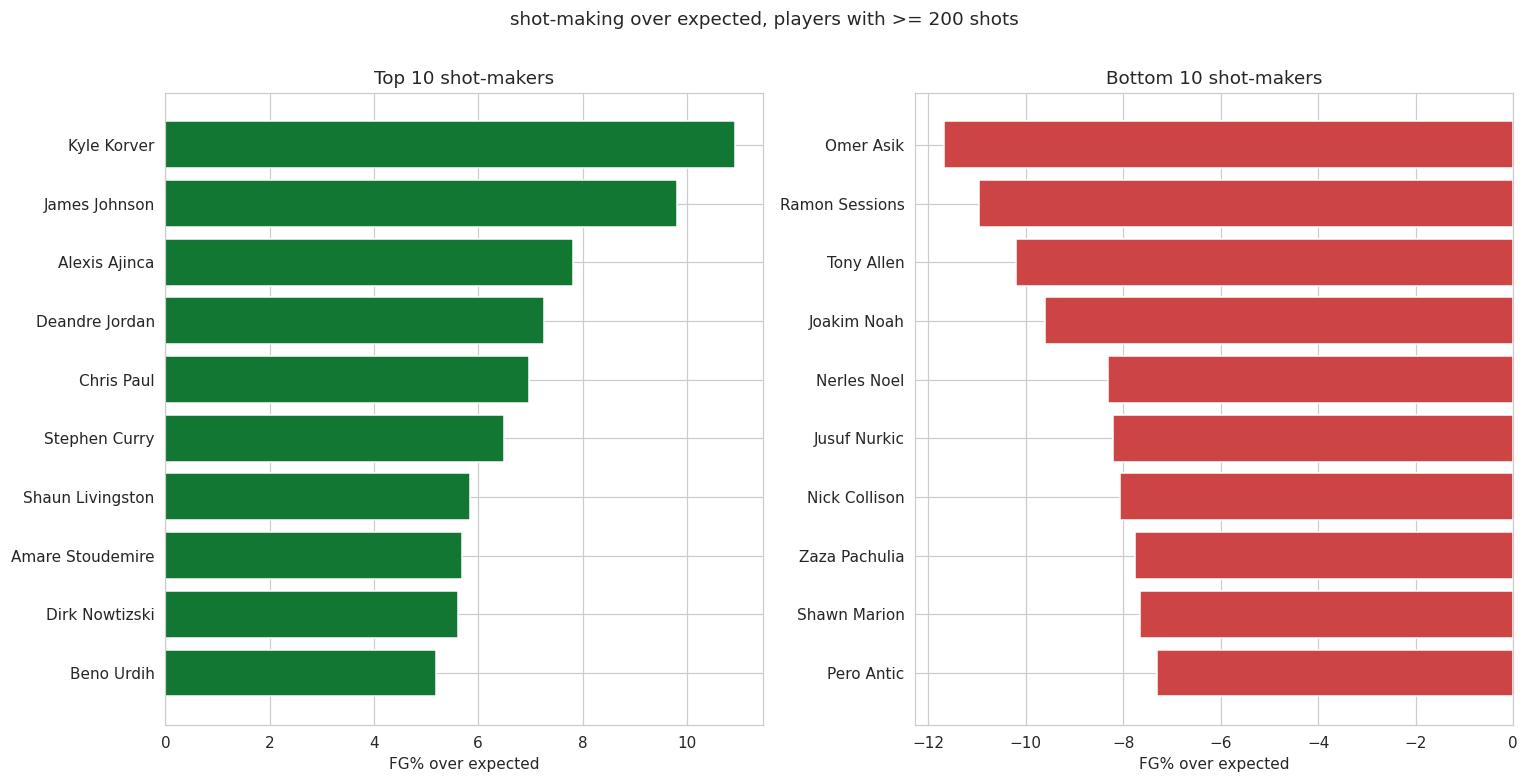

In [ ]:
# Sort ascending so the best player lands at the top of the horizontal bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

t = top10.sort_values("over_expected")
axes[0].barh(t["player_name"], t["over_pct"], color="#117733")
axes[0].set_xlabel("FG% over expected")
axes[0].set_title("Top 10 shot-makers")
axes[0].axvline(0, color="gray", lw=0.5)

b = bot10.sort_values("over_expected", ascending=False)
axes[1].barh(b["player_name"], b["over_pct"], color="#cc4444")
axes[1].set_xlabel("FG% over expected")
axes[1].set_title("Bottom 10 shot-makers")
axes[1].axvline(0, color="gray", lw=0.5)

plt.suptitle(f"shot-making over expected, players with >= {MIN_SHOTS} shots", y=1.01)
plt.tight_layout()
plt.savefig("figures/shot_making.png", bbox_inches="tight")
plt.show()


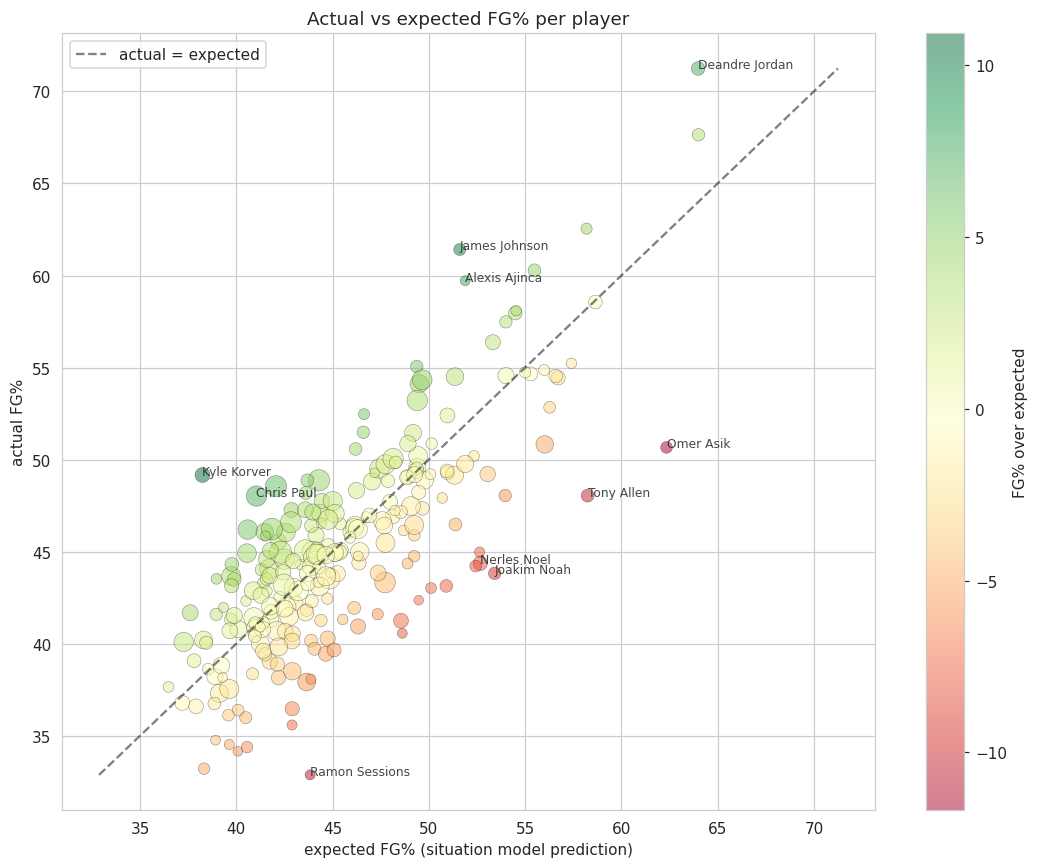

saved to data/player_shot_making.csv


In [ ]:
# Scatter of actual vs expected FG% per player
# Above diagonal = overperformer, below = underperformer, bubble size = shot volume
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(qualified["expected_pct"], qualified["actual_pct"],
                s=qualified["shots"] / 5, alpha=0.5,
                c=qualified["over_pct"], cmap="RdYlGn",
                edgecolor="black", linewidth=0.3)

mn = min(qualified["expected_pct"].min(), qualified["actual_pct"].min())
mx = max(qualified["expected_pct"].max(), qualified["actual_pct"].max())
ax.plot([mn, mx], [mn, mx], "k--", alpha=0.5, label="actual = expected")

notable = pd.concat([top10.head(5), bot10.head(5)])
for _, row in notable.iterrows():
    ax.annotate(row["player_name"], (row["expected_pct"], row["actual_pct"]),
                fontsize=8, alpha=0.85)

ax.set_xlabel("expected FG% (situation model prediction)")
ax.set_ylabel("actual FG%")
ax.set_title("Actual vs expected FG% per player")
plt.colorbar(sc, label="FG% over expected")
ax.legend()
plt.tight_layout()
plt.savefig("figures/actual_vs_expected.png")
plt.show()

qualified.sort_values("over_expected", ascending=False).to_csv(
    "data/player_shot_making.csv", index=False)
print("saved to data/player_shot_making.csv")

## 12. Final results

In [ ]:
# Merge baseline and tuned results into one comparison table
all_results = {**baseline_results, **tuned_results}
final_df = pd.DataFrame(all_results).T.round(4).sort_values("AUC", ascending=False)
print("Final model comparison:")
print()
print(final_df.to_string())
final_df.to_csv("data/final_results.csv")


Final model comparison:

                     Accuracy  LogLoss   Brier     AUC
LightGBM (tuned)       0.6201   0.6476  0.2288  0.6392
XGBoost (tuned)        0.6197   0.6478  0.2289  0.6389
Random Forest          0.6186   0.6486  0.2292  0.6382
MLP                    0.6180   0.6525  0.2307  0.6350
LightGBM               0.6161   0.6495  0.2297  0.6349
Logistic Regression    0.6155   0.6546  0.2315  0.6342
XGBoost                0.6169   0.6497  0.2298  0.6334
Naive (always avg)     0.5479   0.6886  0.2477  0.5000
